# Fakultät für Physik

## Physikalisches Praktikum P2 für Studierende der Physik

Versuch P2-181, 182, 183 (Stand: **März 2025**)

[Raum F1-17](https://labs.physik.kit.edu/img/Klassische-Praktika/Lageplan_P1P2.png)



# Elektrische Bauelemente

Name: __________________ Vorname: __________________ E-Mail: __________________

\begin{equation*}
\begin{split}
&\\
&\\
\end{split}
\end{equation*}

Name: __________________ Vorname: __________________ E-Mail: __________________

\begin{equation*}
\begin{split}
&\\
&\\
&\\
\end{split}
\end{equation*}

Gruppennummer: _____

\begin{equation*}
\begin{split}
&\\
&\\
&\\
\end{split}
\end{equation*}


Betreuer: __________________

\begin{equation*}
\begin{split}
&\\
&\\
&\\
\end{split}
\end{equation*}

Versuch durchgeführt am: __________________

---

**Beanstandungen zu Protokoll Version _____:**

\begin{equation*}
\begin{split}
&\\
&\\
&\\
&\\
&\\
&\\
&\\
&\\
&\\
&\\
\end{split}
%\text{\vspace{10cm}}
\end{equation*}

<br>
Testiert am: __________________ Testat: __________________

# Durchführung

**Detaillierte Kommentare zur Durchführung der Aufgaben finden Sie in der Datei [Elektrische_Bauelemente_Hinweise.ipynb](https://gitlab.kit.edu/kit/etp-lehre/p2-praktikum/students/-/blob/main/Elektrische_Bauelemente/Elektrische_Bauelemente_Hinweise.ipynb)**

## Aufgabe 1: Dioden und verwandte Widerstandstypen

### Aufgabe 1.1: Einfache Dioden und Varistor

 * Charakterisieren Sie die **Kennlinien** der folgenden Dioden- und Widerstandstypen:
   * Si- **oder** Ge-Diode,
   * Z-Diode,
   * Varistor.

---

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from kafe2 import XYFit, XYContainer, Plot, ContoursProfiler, Fit, MultiFit
from uncertainties import ufloat, unumpy, nominal_value, std_dev, umath
from uncertainties.unumpy import nominal_values, std_devs
from uncertainties.umath import * 
from IPython.display import Image
from scipy.interpolate import griddata
from scipy.signal import find_peaks
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML
import matplotlib.image as mpimg
import PhyPraKit
from scipy.optimize import fsolve, fmin
import warnings

# Warnungen unterdrücken
warnings.filterwarnings('ignore', category=RuntimeWarning)

#Abweichung 
def Abweichung(erwartet, ergebnis):
    return 100 * np.abs(erwartet-ergebnis)/erwartet

def n(x):
    return unumpy.nominal_values(x)
def s(x):
    return unumpy.std_devs(x)

# Modellanpassung

def model1():
    return 1
"""
fit1 = Fit(data=[x,y], model_function=model1)
fit1.add_error(axis='x', err_val= )
fit1.add_error(axis='y', err_val= )
fit1.do_fit()
plot = Plot(fit1)
plot.x_label = r'x-Achse'
plot.y_label = r'y-Achse'
plot.customize('data', 'label', "Spannungsübertragung am Hochpass")
plot.plot()
plt.show()
print(fit1.parameter_values[0], "±" , fit1.parameter_errors[0])
print(Abweichung(7234, fit1.parameter_values[0]))"""

'\nfit1 = Fit(data=[x,y], model_function=model1)\nfit1.add_error(axis=\'x\', err_val= )\nfit1.add_error(axis=\'y\', err_val= )\nfit1.do_fit()\nplot = Plot(fit1)\nplot.x_label = r\'x-Achse\'\nplot.y_label = r\'y-Achse\'\nplot.customize(\'data\', \'label\', "Spannungsübertragung am Hochpass")\nplot.plot()\nplt.show()\nprint(fit1.parameter_values[0], "±" , fit1.parameter_errors[0])\nprint(Abweichung(7234, fit1.parameter_values[0]))'

**V E R S U C H S B E S C H R E I B U N G**

*Fügen Sie Ihre Versuchsbeschreibung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

In [49]:
nu = 100 # Hz
R1 = 100 # Ohm
U_schwellen_Si = 0.623 # V
delta_U_schwellen_Si = 0.1 # V
U_schwellen_Z = 0.81 # V
delta_U_schwellen_Z = 0.1 # V
U_Z_0 = -4.616 # V
delta_U_Z_0 = 0.1 # V
U_var = 12.04 # V
delta_U_Schwellen_var = 0.2 # V
U_var_0 = -12.04 # V

### Aufgabe 1.2: Leuchtdiode

 * Stellen Sie die **Kennlinie einer Leuchtdiode** dar. Hierzu stehen Ihnen Leuchtdioden unterschiedlicher Farbe zur Verfügung.
 * Sie können die Kennlinien mehrerer Leuchtdioden vermessen, für Ihre Auswertung genügt jedoch eine.

---

In [50]:
U_LED_schwelle = -2.195 # V
delta_U_LED_schwelle = 0.15 # V

**L Ö S U N G**

*Fügen Sie numerische Berechnungen zur Lösung dieser Aufgabe hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument. Um Code-Fragmente und Skripte in [Python](https://www.python.org/), sowie ggf. bildliche Darstellungen direkt ins [Jupyter notebook](https://jupyter.org/) einzubinden verwandeln Sie diese Zelle in eine Code-Zelle. Fügen Sie ggf. weitere Code-Zellen zu.* 

---

**D I S K U S S I O N**

*Fügen Sie eine abschließende Diskussion und Bewertung Ihrer Lösung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

### Aufgabe 1.3 Photodiode und Photowiderstand

 * Bestimmen Sie die **Kennlinien einer Photodiode** bei verschiedenen Beleuchtungsstärken $E_{\mathrm{V}}$ und bestimmen Sie den den Sperrstrom $I_{S}$ als Funktion von $E_{\mathrm{V}}$.
 * Stellen Sie die **Kennlinien eines Photowiderstands** in beleuchtetem und abgedunkeltem Zustand dar und bestimmen Sie den jeweiligen Widerstand $R$.


---

In [51]:
# Photowiderstahd
y_achse = np.array([-20,20]) # V ch1 mit widerstand
x_achse = np.array([-10.26, 9.782]) # V ch2 photowiderstand
# abgedeckt
y_achse = np.array([-3.384,3.603]) # V ch1 mit widerstand
x_achse = np.array([-14.5, 14.37]) # V ch2 photowiderstand

# Photodiode
U_Photodiode = np.array([1,2,3,4,
                         5,6,7,8,
                         9,10,11,12])
U_schwelle_Pd = np.array([0.895, 0.895, 0.,])
delta_U_schwelle_Pd = np.array([0.15, 0.15])

**L Ö S U N G**

*Fügen Sie numerische Berechnungen zur Lösung dieser Aufgabe hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument. Um Code-Fragmente und Skripte in [Python](https://www.python.org/), sowie ggf. bildliche Darstellungen direkt ins [Jupyter notebook](https://jupyter.org/) einzubinden verwandeln Sie diese Zelle in eine Code-Zelle. Fügen Sie ggf. weitere Code-Zellen zu.* 

---

**D I S K U S S I O N**

*Fügen Sie eine abschließende Diskussion und Bewertung Ihrer Lösung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

## Aufgabe 2: Eigenschaften von Leitern

### Aufgabe 2.1: Abhängigkeit vom Druck

 * Führen Sie mit dem Oszilloskop qualitative Untersuchungen an verschiedenen **Piezoelementen** durch.

---

**V E R S U C H S B E S C H R E I B U N G**

*Fügen Sie Ihre Versuchsbeschreibung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

### Aufgabe 2.2: Abhängigkeit von der Temperatur

 * Untersuchen Sie mit Hilfe eines Ofens die Abhängigkeiten der Widerstände eines (NTC) **Heissleiters** und eines (PTC) **Kaltleiters** von der Temperatur zwischen $\vartheta=60$ und $200^{\circ}\mathrm{C}$.

---

**V E R S U C H S B E S C H R E I B U N G**

*Fügen Sie Ihre Versuchsbeschreibung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

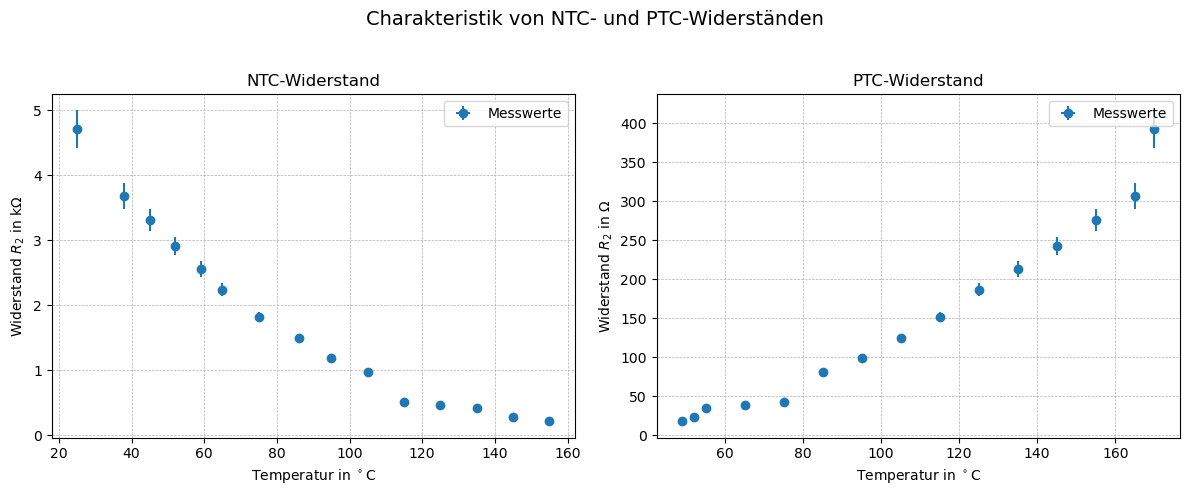

In [52]:
# Messreihe für NTC Widerstand
delta_T = 0.5
delta_U = 0.1
R_0_ntc = ufloat(1.2, 0.012) # kOhm
R_pot_ntc_0 = 10 # V
Temp_ntc = np.array([25, 38, 45, 52, 59, 65, 75, 86, 95, 105, 115, 125, 135, 145, 155 ]) # Degrees
U_ntc = np.array([7.97, 7.54, 7.34, 7.08, 6.81, 6.51, 6.02, 5.54, 4.98, 4.47, 2.98, 2.77, 2.57, 1.86, 1.53 ]) # V -  anzeige am Potentiometer
u_Temp_ntc = unumpy.uarray(Temp_ntc, delta_T)
u_U_ntc = unumpy.uarray(U_ntc, delta_U)

R_ntc = ( u_U_ntc / (10 - u_U_ntc) ) * R_0_ntc

# Messreihe für PTC Widerstand
R_0_ptc = ufloat(100,1) # Ohm
T_ptc = np.array([170, 165, 155, 145, 135, 125, 115, 105, 95, 85, 75, 65, 55, 52, 49]) # Degrees         
U_ptc = np.array([6.23, 6.1, 6.05, 5.96, 5.88, 5.85, 5.81, 5.74, 5.68, 5.61, 5.56, 5.5, 5.45, 5.42, 5.4 ]) # kOhm
u_Temp_ptc = unumpy.uarray(T_ptc, delta_T)
u_U_ptc = unumpy.uarray(U_ptc, delta_U)


R_pot_ptc = ( u_U_ntc / (10 - u_U_ntc) ) * R_0_ptc

# Erstelle Subplots: 1 Zeile, 2 Spalten
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# Plot NTC
axs[0].errorbar(unumpy.nominal_values(u_Temp_ntc), unumpy.nominal_values(R_ntc),
                xerr=unumpy.std_devs(u_Temp_ntc), yerr=unumpy.std_devs(R_ntc),
                fmt='o', label='Messwerte')
axs[0].set_xlabel(r'Temperatur in $^\circ$C')
axs[0].set_ylabel(r'Widerstand $R_2$ in k$\Omega$')
axs[0].set_title('NTC-Widerstand')
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].legend()

# Plot PTC
axs[1].errorbar(unumpy.nominal_values(u_Temp_ptc), unumpy.nominal_values(R_pot_ptc),
                xerr=unumpy.std_devs(u_Temp_ptc), yerr=unumpy.std_devs(R_pot_ptc),
                fmt='o', label='Messwerte')
axs[1].set_xlabel(r'Temperatur in $^\circ$C')
axs[1].set_ylabel(r'Widerstand $R_2$ in $\Omega$')
axs[1].set_title('PTC-Widerstand')
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].legend()

# Optional: Gesamttitel und Layout anpassen
fig.suptitle('Charakteristik von NTC- und PTC-Widerständen', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # Platz für Titel lassen

plt.show()

**D I S K U S S I O N**

*Fügen Sie eine abschließende Diskussion und Bewertung Ihrer Lösung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

### Aufgabe 2.3: Hochtemperatursupraleitung

 * Bestimmen Sie die **Sprungtemperatur eines Hochtemperatursupraleiters**.

---

**V E R S U C H S B E S C H R E I B U N G**

*Fügen Sie Ihre Versuchsbeschreibung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

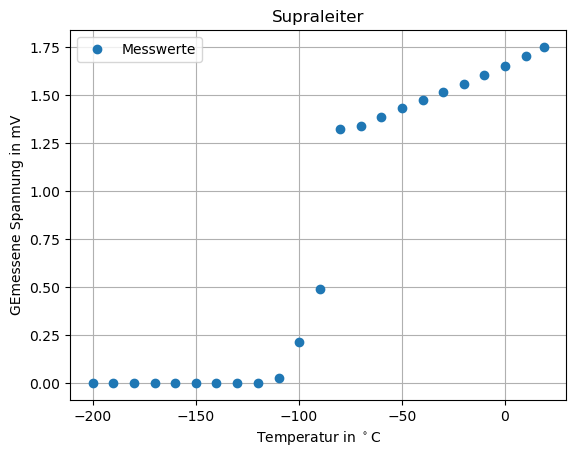

In [53]:
# 77 k bei -168 C
T_super = np.array([18.8, 10, 0, -10, -20,
                    -30, -40, -50, -60, -70,
                    -80, -89.8, -100, -109.9, -120, 
                    -130, -140, -150, -160, -170,
                    -180, -190, -200]) # grad C
U_super = np.array([1.751, 1.705, 1.653, 1.603, 1.560, 
                    1.517, 1.477, 1.435, 1.386, 1.338,
                    1.323, 0.49, 0.215, 0.027, 0.001, 
                    0.001, 0.001, 0.00, 0.001, 0.001, 
                    0,0,0
                    ]) # mVDC

# Plot U(T)
plt.plot(T_super, U_super, 'o', label='Messwerte')
plt.xlabel(r'Temperatur in $^\circ$C')
plt.ylabel(r'GEmessene Spannung in mV')
plt.title('Supraleiter')
plt.grid()
plt.legend()
plt.show()


**D I S K U S S I O N**

*Fügen Sie eine abschließende Diskussion und Bewertung Ihrer Lösung hier ein. Löschen Sie hierzu diesen kursiv gestellten Text aus dem Dokument.* 

---

# Beurteilung

 * Beurteilen Sie diesen Versuch nach Abschluss der Auswertung.
 * **Folgen Sie zur Beurteilung dieses Versuchs diesem [Link](https://www.empirio.de/s/UWm=UUYWWR)**.
 * Beachten Sie, dass jede:r Studierende nur einmal pro Versuch eine Beurteilung abgeben kann.

**Lösung:**

Fügen Sie Ihrem Protokoll einen Screenshot der letzten Informationsseite der oben verlinkten Beurteilung zu.